# Rotation and Translation Checker and Visualizer for FK

In [2]:
!pip install numpy matplotlib ipympl


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%matplotlib widget

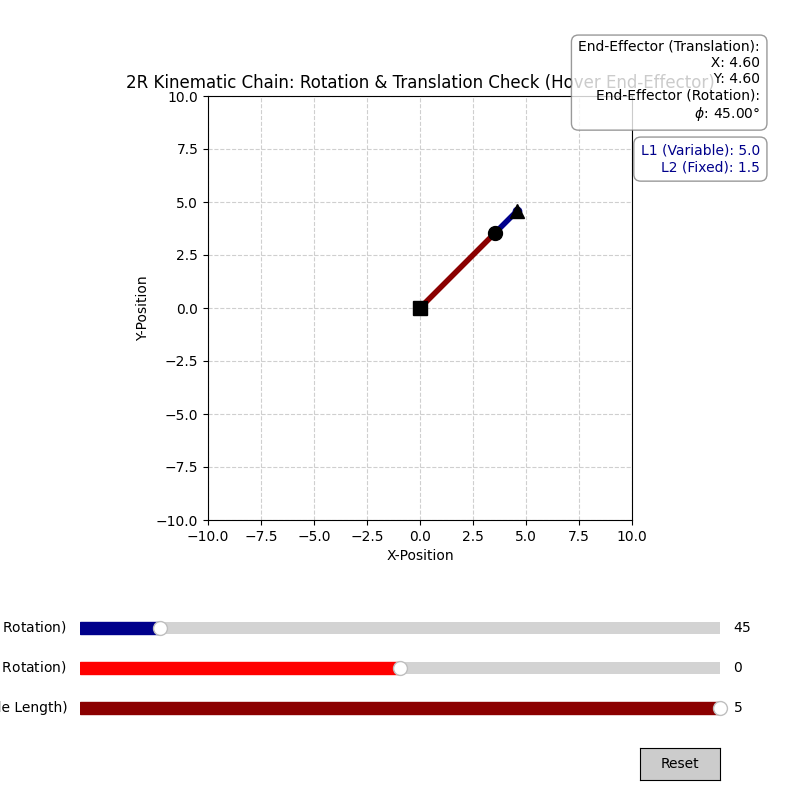

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button

# --- Configuration ---
# Fixed length for the second link (L2) - Now fixed
L2_FIXED = 1.5
# Initial values
THETA1_INITIAL = 45  # degrees
THETA2_INITIAL = 0    # degrees
L1_INITIAL = 5.0      # variable length for the first link (L1 is now variable)

# Global variables to store the end-effector coordinates for the hover function
EE_X_POS = 0.0
EE_Y_POS = 0.0

# --- Setup Plot and Figure ---
fig, ax = plt.subplots(figsize=(8, 8))
# Adjust space for sliders (bottom=0.35) and ensure space for text on the right (right=0.95)
plt.subplots_adjust(left=0.1, bottom=0.35, right=0.95) 
ax.set_aspect('equal', adjustable='box')
ax.set_title("2R Kinematic Chain: Rotation & Translation Check (Hover End-Effector)")
ax.set_xlabel("X-Position")
ax.set_ylabel("Y-Position")
ax.grid(True, linestyle='--', alpha=0.6) # Grid is active

# Set axes limits dynamically (Max reach is L1 max (5.0) + L2 fixed (3.0) = 8.0)
max_range = 10.0 # Sufficient margin for max reach
ax.set_xlim(-max_range, max_range)
ax.set_ylim(-max_range, max_range)

# --- Drawing Elements ---
# Line objects for the two links (L1 is now variable, L2 is now fixed)
line1, = ax.plot([0, 0], [0, 0], 'o-', lw=4, color='darkred', label='Link 1 (Variable)')
line2, = ax.plot([0, 0], [0, 0], 'o-', lw=4, color='darkblue', label='Link 2 (Fixed)')

# Joint markers
joint0, = ax.plot(0, 0, 'ks', ms=10, label='Base Joint (0,0)')
joint1, = ax.plot(0, 0, 'ko', ms=10, label='Joint 1')
ee_point, = ax.plot(0, 0, 'k^', ms=10, label='End-Effector (P_EE)') # End-Effector point

# Text annotation for coordinates and overall rotation (MOVED TO TOP RIGHT)
# Updated to position text on the top right margin of the figure for clarity.
coord_text = fig.text(0.95, 0.95, '', fontsize=10, verticalalignment='top', horizontalalignment='right', 
                      bbox=dict(boxstyle="round,pad=0.5", fc="white", alpha=0.8, ec="grey"))
link_length_text = fig.text(0.95, 0.82, f'L2: {L2_FIXED:.1f}', fontsize=10, verticalalignment='top', horizontalalignment='right', color='darkblue',
                            bbox=dict(boxstyle="round,pad=0.5", fc="white", alpha=0.8, ec="grey"))

# --- Annotation for Hover ---
# Initialize the annotation object, hidden initially
annotation = ax.annotate(
    '', xy=(0, 0), xytext=(20, 20), textcoords='offset points',
    bbox=dict(boxstyle="round,pad=0.5", fc="yellow", alpha=0.7),
    arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.2", color='black'),
    visible=False
)

# --- Forward Kinematics Function ---
def forward_kinematics(theta1_deg, theta2_deg, l1_var): # l1_var is now the variable length
    """Calculates the positions of the joints and end-effector."""
    # Convert angles to radians
    th1 = np.deg2rad(theta1_deg)
    th2 = np.deg2rad(theta2_deg)
    th_ee = th1 + th2

    # Joint 1 Position (P1)
    p1_x = l1_var * np.cos(th1) # Uses variable L1
    p1_y = l1_var * np.sin(th1) # Uses variable L1

    # End-Effector Position (PEE)
    pee_x = p1_x + L2_FIXED * np.cos(th_ee) # Uses fixed L2
    pee_y = p1_y + L2_FIXED * np.sin(th_ee) # Uses fixed L2

    # End-Effector Orientation (Rotation)
    phi_deg = theta1_deg + theta2_deg

    return p1_x, p1_y, pee_x, pee_y, phi_deg

# --- Update Function for Sliders ---
def update(val):
    """Updates the plot based on slider values."""
    global EE_X_POS, EE_Y_POS # Declare globals to modify them
    
    # Get values from sliders
    th1_deg = s_theta1.val
    th2_deg = s_theta2.val
    l1 = s_l1.val # Now getting L1 from the slider

    # Calculate kinematics
    p1_x, p1_y, pee_x, pee_y, phi_deg = forward_kinematics(th1_deg, th2_deg, l1)

    # Update global EE position for the hover handler
    EE_X_POS = pee_x
    EE_Y_POS = pee_y
    
    # Update Link 1 plot (Base to Joint 1)
    line1.set_data([0, p1_x], [0, p1_y])
    
    # FIX: Wrap scalar coordinates in a list for the joint marker
    joint1.set_data([p1_x], [p1_y])

    # Update Link 2 plot (Joint 1 to End-Effector)
    line2.set_data([p1_x, pee_x], [p1_y, pee_y])
    
    # FIX: Wrap scalar coordinates in a list for the end-effector marker
    ee_point.set_data([pee_x], [pee_y])

    # Update static coordinate text
    coord_text.set_text(
        f'End-Effector (Translation):\n'
        f'  X: {pee_x:.2f}\n'
        f'  Y: {pee_y:.2f}\n'
        f'End-Effector (Rotation):\n'
        f'  $\\phi$: {phi_deg:.2f}°'
    )
    link_length_text.set_text(
        f'L1 (Variable): {l1:.1f}\n'
        f'L2 (Fixed): {L2_FIXED:.1f}'
    )

    fig.canvas.draw_idle()

# --- Mouse Move Handler Function ---
def on_move(event):
    """Handles mouse movement to display end-effector coordinates on hover."""
    # Check if the event occurred within the main axes and has data coordinates
    if event.inaxes != ax or event.xdata is None or event.ydata is None:
        # If the mouse leaves the plot area, hide the annotation
        if annotation.get_visible():
            annotation.set_visible(False)
            fig.canvas.draw_idle()
        return

    # Use the global EE positions updated by the slider
    ee_x = EE_X_POS
    ee_y = EE_Y_POS

    # Calculate distance from mouse pointer to the End-Effector point
    dist = np.sqrt((event.xdata - ee_x)**2 + (event.ydata - ee_y)**2)
    
    # Threshold for proximity (in data units) - determines how close the mouse must be
    threshold = 0.5 

    if dist < threshold:
        # Update annotation position and text
        annotation.xy = (ee_x, ee_y)
        annotation.set_text(f'P_EE:\n(X: {ee_x:.2f}, Y: {ee_y:.2f})')
        
        # Make visible and redraw if not already
        if not annotation.get_visible():
            annotation.set_visible(True)
            fig.canvas.draw_idle()
    else:
        # Hide annotation if cursor is outside the threshold
        if annotation.get_visible():
            annotation.set_visible(False)
            fig.canvas.draw_idle()

# --- Slider Definitions ---
# Define axis for the sliders
ax_t1 = plt.axes([0.1, 0.20, 0.8, 0.03], facecolor='#f0f0f0')
ax_t2 = plt.axes([0.1, 0.15, 0.8, 0.03], facecolor='#f0f0f0')
ax_l1 = plt.axes([0.1, 0.10, 0.8, 0.03], facecolor='#f0f0f0') # L1 is now on the bottom slider

# Slider for Joint 1 Angle (Theta 1)
s_theta1 = Slider(
    ax_t1, '$\\theta_1$ (Base Rotation)', 0, 360,
    valinit=THETA1_INITIAL, valstep=1, color='darkblue'
)

# Slider for Joint 2 Angle (Theta 2) - relative to Link 1
s_theta2 = Slider(
    ax_t2, '$\\theta_2$ (Relative Rotation)', -180, 180,
    valinit=THETA2_INITIAL, valstep=1, color='red'
)

# Slider for Link 1 Length (L1) - Now Variable
s_l1 = Slider(
    ax_l1, 'L1 (Variable Length)', 1.0, 5.0,
    valinit=L1_INITIAL, valstep=0.1, color='darkred'
)

# Connect sliders to the update function
s_theta1.on_changed(update)
s_theta2.on_changed(update)
s_l1.on_changed(update)

# --- Reset Button ---
ax_reset = plt.axes([0.8, 0.025, 0.1, 0.04])
button = Button(ax_reset, 'Reset', color='#cccccc', hovercolor='0.975')

def reset(event):
    s_theta1.reset()
    s_theta2.reset()
    s_l1.reset()
button.on_clicked(reset)

# --- Connect Mouse Event ---
# This connects the mouse motion to our hover function
fig.canvas.mpl_connect('motion_notify_event', on_move)

# Initial call to update the plot with initial values
update(None)

# Display legend and plot
# plt.show() # Commented out for smoother notebook/interactive environment execution
